[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-foundations/torch_measure/blob/main/tutorials/metr_agentic_evaluation.ipynb)

# Agentic Evaluation: IRT Analysis of AI Agent Capabilities

This tutorial demonstrates how to use **torch_measure** to analyze agentic evaluation datasets. We use the [Cybench](https://arxiv.org/abs/2408.08926) CTF agent benchmark from measurement-db as a running example — 8 LLM agents evaluated across 40 cybersecurity capture-the-flag tasks, with continuous subtask-fraction scores that are well-suited to **Beta IRT**.

The same workflow applies to other agentic benchmarks in measurement-db (e.g. `androidworld`, `bfcl` private) and to the original METR [eval-analysis-public](https://github.com/METR/eval-analysis-public) data.

**What you'll learn:**
1. Loading the dataset from the `torch_measure.datasets` registry (long-form native, then pivot to wide)
2. Exploring the response matrix structure and metadata
3. Fitting **Beta IRT** models (BetaRasch, BetaTwoPL) for continuous pass-rate data
4. Comparing agent abilities and task difficulties
5. Evaluating model fit with train/test splitting and psychometric metrics
6. Visualizing item characteristic curves and ability rankings

## 1. Setup

In [1]:
try:
    import google.colab
    !git clone https://github.com/aims-foundations/torch_measure.git
    !pip install -e "torch_measure[data]"
except ImportError:
    pass  # Already installed locally

import torch
import matplotlib.pyplot as plt
import numpy as np

from torch_measure.datasets import load, list_datasets, info
from torch_measure.data import ResponseMatrix, random_mask, binarize
from torch_measure.models import BetaRasch, BetaTwoPL, Rasch, TwoPL
from torch_measure.metrics import (
    expected_calibration_error, brier_score,
    cronbach_alpha, infit_statistics, outfit_statistics,
    ability_standard_errors, difficulty_standard_errors,
)

plt.rcParams["figure.dpi"] = 120
torch.manual_seed(42)
print("Setup complete.")

Setup complete.


---
## Part 1: Ground-Truth Recovery on Synthetic Beta-IRT Data

Cybench has continuous pass-rate responses in (0, 1) — the natural fit for Beta IRT. Before applying BetaRasch to the real data we check it can recover known parameters on synthetic Beta-IRT-generated responses with known ability and difficulty.

In [2]:
# Generate synthetic Beta-IRT continuous responses
torch.manual_seed(0)

N_SYN, M_SYN = 100, 60
true_ability_syn = torch.randn(N_SYN)
true_difficulty_syn = torch.randn(M_SYN)
phi_syn = 10.0

# Mean parameter of Beta
mu_syn = torch.sigmoid(true_ability_syn.unsqueeze(1) - true_difficulty_syn.unsqueeze(0))
# Sample from Beta(mu*phi, (1-mu)*phi)
alpha = mu_syn * phi_syn
beta = (1 - mu_syn) * phi_syn
syn_responses = torch.distributions.Beta(alpha, beta).sample()
# Clamp for numerical safety
syn_responses = syn_responses.clamp(1e-4, 1 - 1e-4)
print(f"Synthetic: {N_SYN} subjects x {M_SYN} items, mean={syn_responses.mean():.3f}")


Synthetic: 100 subjects x 60 items, mean=0.495


In [3]:
# Fit BetaRasch and check parameter recovery
beta_syn = BetaRasch(n_subjects=N_SYN, n_items=M_SYN, phi=phi_syn)
hist_syn = beta_syn.fit(syn_responses, max_epochs=200, lr=0.05, verbose=False)

est_ab_syn = beta_syn.ability.detach()
est_diff_syn = beta_syn.difficulty.detach()

r_ab = torch.corrcoef(torch.stack([true_ability_syn, est_ab_syn]))[0, 1].item()
r_diff = torch.corrcoef(torch.stack([true_difficulty_syn, est_diff_syn]))[0, 1].item()
print(f"Ability recovery:   r = {r_ab:.3f}")
print(f"Difficulty recovery: r = {r_diff:.3f}")


Ability recovery:   r = 0.996
Difficulty recovery: r = 0.997


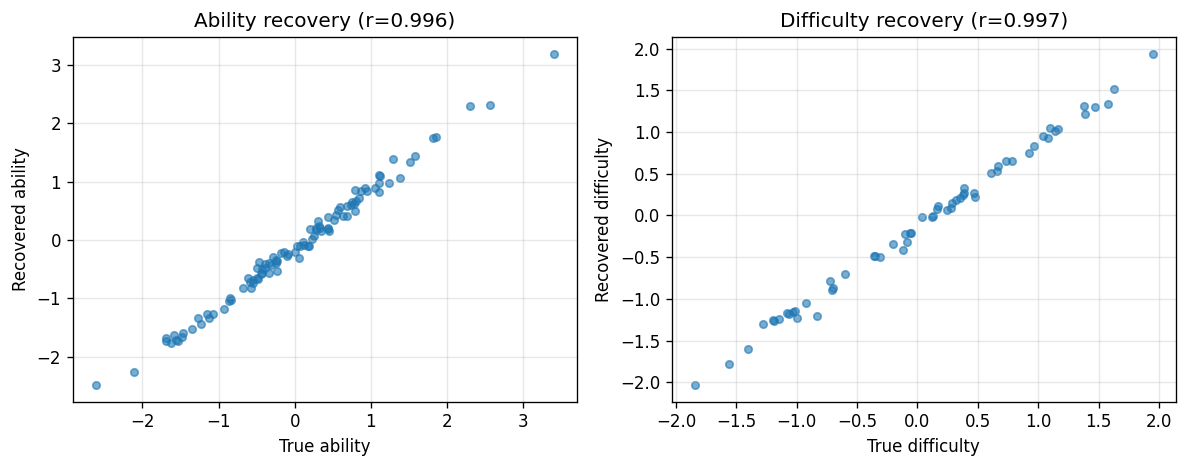

In [4]:
# Plot recovery
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(true_ability_syn.numpy(), est_ab_syn.numpy(), alpha=0.6, s=20)
axes[0].set_xlabel("True ability"); axes[0].set_ylabel("Recovered ability")
axes[0].set_title(f"Ability recovery (r={r_ab:.3f})")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(true_difficulty_syn.numpy(), est_diff_syn.numpy(), alpha=0.6, s=20)
axes[1].set_xlabel("True difficulty"); axes[1].set_ylabel("Recovered difficulty")
axes[1].set_title(f"Difficulty recovery (r={r_diff:.3f})")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


BetaRasch cleanly recovers both the subject abilities and the item difficulties on synthetic data. With the mechanic validated, we switch to real agentic-benchmark data.

---
## Part 2: Real Benchmark — Cybench (from here on, existing content)

## 2. Explore Available Datasets

`torch_measure.datasets` offers access to measurement-db benchmarks. We'll use `cybench` — continuous fractional scores from a CTF agent benchmark (8 LLM agents × 40 tasks). The values are already in [0, 1], making them a natural fit for Beta IRT.

In [5]:
print("Available datasets:")
for name in list_datasets():
    ds_info = info(name)
    print(f"  {name:25s}  response_type={ds_info.response_type:<12}  —  {ds_info.description[:70]}")

Available datasets:


  afrimedqa                  response_type=binary        —  AfriMed-QA: medical QA for African healthcare contexts; binary correct
  androidworld               response_type=binary        —  AndroidWorld: 116-task Android agent benchmark; per-task data from 3 p
  cybench                    response_type=fraction      —  Cybench CTF agent benchmark: 8 models x 40 tasks, unguided + subtask-g
  matharena                  response_type=mixed         —  MathArena: uncontaminated math competitions (27 datasets); final-answe
  mtbench                    response_type=likert_10     —  MT-Bench GPT-4 single-answer judgment scores (34 models, 80 questions,
  ultrafeedback              response_type=likert_5      —  UltraFeedback GPT-4 multi-aspect ratings (1-5) from 17 models on ~64K 


## 3. Load and Explore the Data

In [6]:
# Load the dataset (long-form native); pivot to a ResponseMatrix for this tutorial
data = load("cybench")
rm = data.to_response_matrix()
print(rm)
print(f"Density (fraction observed): {rm.density:.1%}")
print(f"Overall mean score: {rm.data[rm.observed_mask].mean():.3f}")
print(f"\nNumber of agents: {rm.n_subjects}")
print(f"Number of tasks: {rm.n_items}")

ResponseMatrix(n_subjects=8, n_items=40, density=100.00%)
Density (fraction observed): 100.0%
Overall mean score: 0.157

Number of agents: 8
Number of tasks: 40


In [7]:
# Inspect agents (subjects)
print("Agents and their mean pass rates:")
agent_means = rm.subject_means
ranking = agent_means.argsort(descending=True)

# Join against the subjects registry in the LongFormData for richer metadata
subj_df = data.subjects.set_index("subject_id") if "subject_id" in data.subjects.columns else None

for rank, idx in enumerate(ranking):
    name = rm.subject_ids[idx]
    provider = ""
    if subj_df is not None and name in subj_df.index and "provider" in subj_df.columns:
        provider = str(subj_df.at[name, "provider"])
    print(f"  {rank+1:2d}. {name:40s}  pass_rate={agent_means[idx]:.3f}  provider={provider}")

Agents and their mean pass rates:
   1. Claude 3.5 Sonnet                         pass_rate=0.257  provider=
   2. OpenAI o1-preview                         pass_rate=0.223  provider=
   3. gpt-4o                                    pass_rate=0.198  provider=
   4. Claude 3 Opus                             pass_rate=0.196  provider=
   5. Llama 3.1 405B Instruct                   pass_rate=0.143  provider=
   6. Mixtral 8x22b Instruct                    pass_rate=0.093  provider=
   7. Gemini 1.5 Pro                            pass_rate=0.078  provider=
   8. Llama 3 70b Chat                          pass_rate=0.068  provider=


In [8]:
# Inspect tasks (items) — show easiest and hardest
task_means = rm.item_means
task_ranking = task_means.argsort(descending=True)

print("Easiest 5 tasks (highest pass rate):")
for idx in task_ranking[:5]:
    print(f"  {rm.item_ids[idx]:50s}  pass_rate={task_means[idx]:.3f}")

print("\nHardest 5 tasks (lowest pass rate):")
for idx in task_ranking[-5:]:
    print(f"  {rm.item_ids[idx]:50s}  pass_rate={task_means[idx]:.3f}")

Easiest 5 tasks (highest pass rate):
  d151df23f492d444                                    pass_rate=0.694
  1e302b17ac8614c1                                    pass_rate=0.681
  f932d4704ae65014                                    pass_rate=0.611
  2fe857c25037bc5b                                    pass_rate=0.592
  8a4d44934674d5a9                                    pass_rate=0.438

Hardest 5 tasks (lowest pass rate):
  984cb624bd52eb02                                    pass_rate=0.010
  cade4b66d1c5330d                                    pass_rate=0.010
  6c02e94652fa3422                                    pass_rate=0.007
  17a68f96e6a2591d                                    pass_rate=0.000
  e1ecc80dd5be4c1e                                    pass_rate=0.000


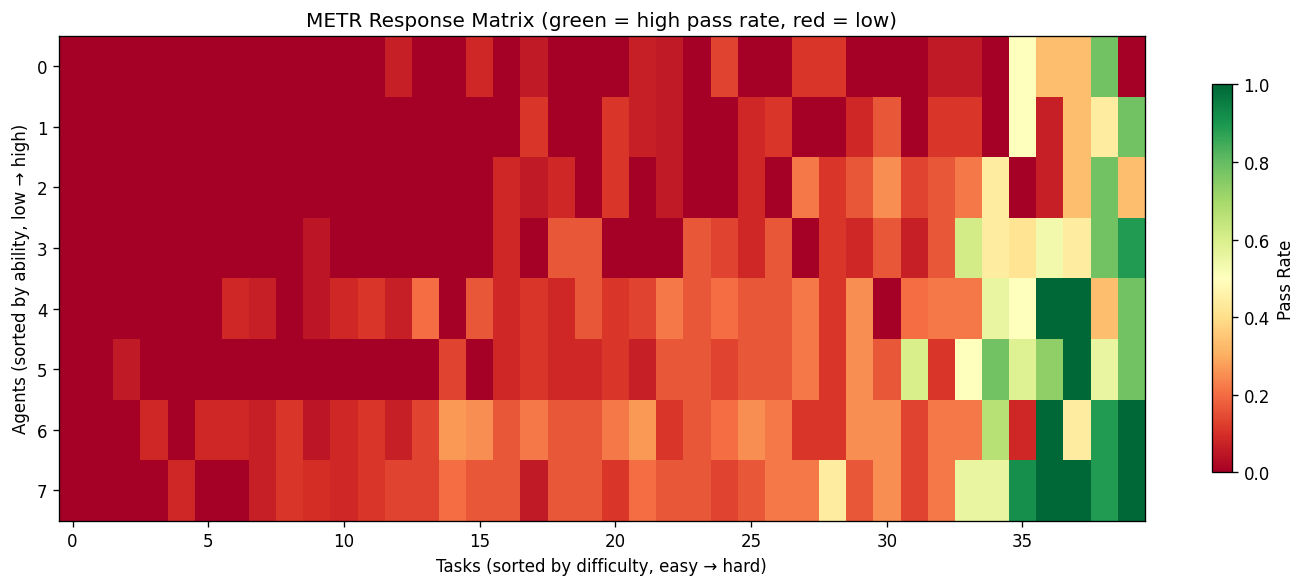

The Guttman pattern is visible: capable agents (top) pass more tasks.


In [9]:
# Visualize the response matrix sorted by agent ability and task difficulty
sorted_subj = agent_means.argsort()
sorted_item = task_means.argsort()
sorted_data = rm.data[sorted_subj][:, sorted_item]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(sorted_data.numpy(), aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")
ax.set_xlabel("Tasks (sorted by difficulty, easy → hard)")
ax.set_ylabel("Agents (sorted by ability, low → high)")
ax.set_title("METR Response Matrix (green = high pass rate, red = low)")
plt.colorbar(im, ax=ax, shrink=0.8, label="Pass Rate")
plt.tight_layout()
plt.show()
print("The Guttman pattern is visible: capable agents (top) pass more tasks.")

## 4. Fitting Beta IRT Models

Since the METR data has continuous [0, 1] pass rates (averaged over multiple runs), we use **Beta IRT** models. These model the response probability as:

- **Beta-Rasch**: $\mu_{ij} = \sigma(\theta_i - b_j)$, with Beta likelihood parameterized by $(\mu, \phi)$
- **Beta-2PL**: $\mu_{ij} = \sigma(a_j(\theta_i - b_j))$, adding item discrimination $a_j$

where $\theta_i$ is agent ability, $b_j$ is task difficulty, and $\phi$ is the precision parameter.

In [10]:
n_subjects, n_items = rm.n_subjects, rm.n_items

# Clamp values away from exact 0 and 1 for Beta likelihood
data = rm.data.clone()
eps = 1e-4
data = data.clamp(eps, 1 - eps)

# Fit Beta-Rasch
beta_rasch = BetaRasch(n_subjects=n_subjects, n_items=n_items, phi=10.0)
history_br = beta_rasch.fit(data, max_epochs=200, lr=0.01, verbose=True)
print(f"Beta-Rasch final loss: {history_br['losses'][-1]:.4f}")

# Fit Beta-2PL
beta_2pl = BetaTwoPL(n_subjects=n_subjects, n_items=n_items, phi=10.0)
history_b2 = beta_2pl.fit(data, max_epochs=200, lr=0.01, verbose=True)
print(f"Beta-2PL final loss: {history_b2['losses'][-1]:.4f}")

MLE fitting:   0%|          | 0/500 [00:00<?, ?it/s]

MLE fitting:   0%|          | 0/500 [00:00<?, ?it/s, loss=11.846266]

MLE fitting:   0%|          | 0/500 [00:00<?, ?it/s, loss=11.691126]

MLE fitting:   0%|          | 0/500 [00:00<?, ?it/s, loss=11.536900]

MLE fitting:   0%|          | 0/500 [00:00<?, ?it/s, loss=11.383615]

...

MLE fitting:  91%|█████████▏| 457/500 [00:01<00:00, 414.01it/s, loss=-2.579682]

MLE fitting:  91%|█████████▏| 457/500 [00:01<00:00, 414.01it/s, loss=-2.581188]

MLE fitting:  91%|█████████▏| 457/500 [00:01<00:00, 414.01it/s, loss=-2.582674]

MLE fitting: 100%|██████████| 500/500 [00:01<00:00, 414.10it/s, loss=-2.582674]

Beta-2PL final loss: -2.5827


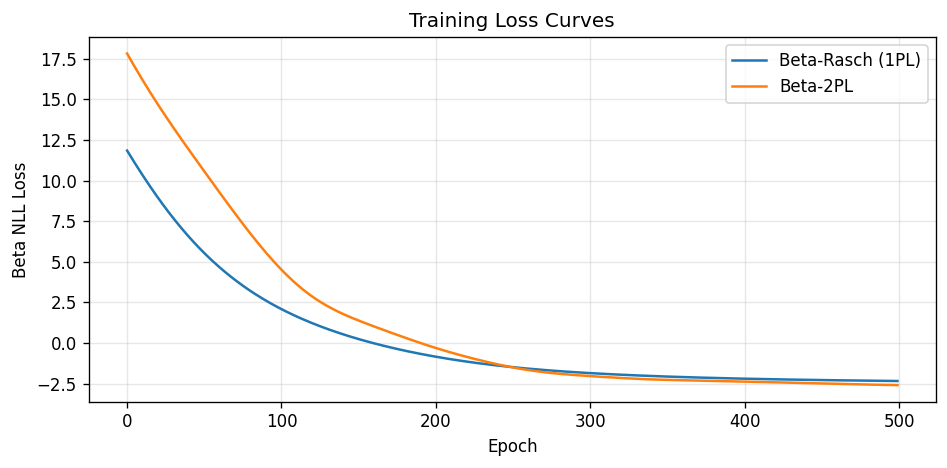

In [11]:
# Compare training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_br["losses"], label="Beta-Rasch (1PL)")
ax.plot(history_b2["losses"], label="Beta-2PL")
ax.set_xlabel("Epoch")
ax.set_ylabel("Beta NLL Loss")
ax.set_title("Training Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Agent Ability Rankings

The IRT ability parameter $\theta_i$ provides a principled ranking of agents that accounts for task difficulty — unlike raw pass rates which treat all tasks equally.

In [12]:
ability = beta_2pl.ability.detach()
ability_ranking = ability.argsort(descending=True)

print(f"{'Rank':<5} {'Agent':<38} {'IRT Ability':>12} {'Pass Rate':>10}  {'Provider'}")
print("-" * 80)
for rank, idx in enumerate(ability_ranking):
    name = rm.subject_ids[idx]
    provider = ""
    if subj_df is not None and name in subj_df.index and "provider" in subj_df.columns:
        provider = str(subj_df.at[name, "provider"])
    print(f"{rank+1:<5d} {name:<38s} {ability[idx]:>12.3f} {agent_means[idx]:>10.3f}  {provider}")

Rank  Agent                                   IRT Ability  Pass Rate  Provider
--------------------------------------------------------------------------------
1     Claude 3.5 Sonnet                             0.185      0.257  
2     OpenAI o1-preview                             0.149      0.223  
3     Claude 3 Opus                                -0.082      0.196  
4     gpt-4o                                       -0.428      0.198  
5     Llama 3.1 405B Instruct                      -0.837      0.143  
6     Llama 3 70b Chat                             -1.206      0.068  
7     Gemini 1.5 Pro                               -1.209      0.078  
8     Mixtral 8x22b Instruct                       -1.274      0.093  


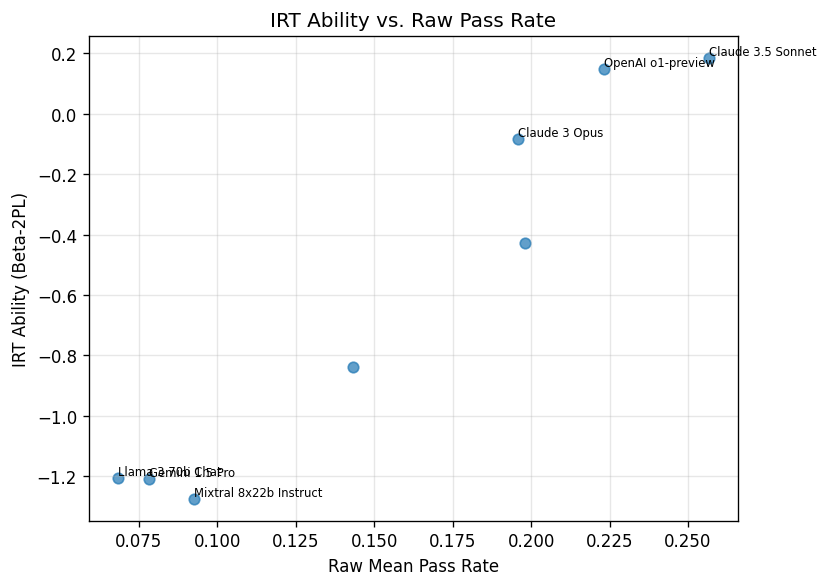

Correlation: 0.970 — mostly monotone, but IRT reweights by task difficulty.


In [13]:
# Compare IRT ability vs. raw pass rate
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(agent_means.numpy(), ability.numpy(), s=40, alpha=0.7)

# Label a few notable agents
for idx in list(ability_ranking[:3]) + list(ability_ranking[-3:]):
    ax.annotate(
        rm.subject_ids[idx],
        (agent_means[idx].item(), ability[idx].item()),
        fontsize=7, ha="left", va="bottom",
    )

ax.set_xlabel("Raw Mean Pass Rate")
ax.set_ylabel("IRT Ability (Beta-2PL)")
ax.set_title("IRT Ability vs. Raw Pass Rate")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
r = torch.corrcoef(torch.stack([agent_means, ability]))[0, 1]
print(f"Correlation: {r:.3f} — mostly monotone, but IRT reweights by task difficulty.")

## 6. Task Difficulty Analysis

IRT difficulty parameters $b_j$ provide a calibrated difficulty scale. The 2PL model also estimates discrimination $a_j$ — how sharply each task distinguishes between agents of different ability.

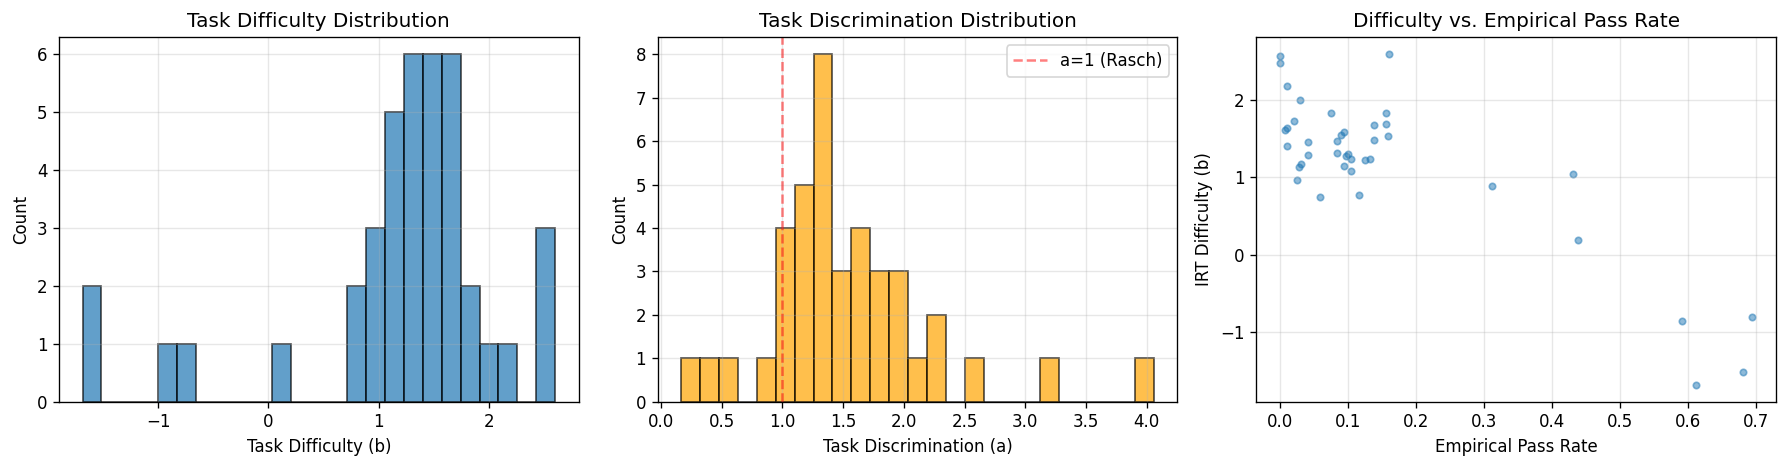

In [14]:
difficulty = beta_2pl.difficulty.detach()
discrimination = beta_2pl.discrimination.detach()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Difficulty distribution
axes[0].hist(difficulty.numpy(), bins=25, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Task Difficulty (b)")
axes[0].set_ylabel("Count")
axes[0].set_title("Task Difficulty Distribution")
axes[0].grid(True, alpha=0.3)

# Discrimination distribution
axes[1].hist(discrimination.numpy(), bins=25, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_xlabel("Task Discrimination (a)")
axes[1].set_ylabel("Count")
axes[1].set_title("Task Discrimination Distribution")
axes[1].axvline(x=1.0, color="red", linestyle="--", alpha=0.5, label="a=1 (Rasch)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Difficulty vs. empirical pass rate
axes[2].scatter(task_means.numpy(), difficulty.numpy(), alpha=0.5, s=15)
axes[2].set_xlabel("Empirical Pass Rate")
axes[2].set_ylabel("IRT Difficulty (b)")
axes[2].set_title("Difficulty vs. Empirical Pass Rate")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Show highest and lowest discrimination tasks
disc_ranking = discrimination.argsort(descending=True)

print("Top 5 most discriminating tasks (best at separating agent ability):")
for idx in disc_ranking[:5]:
    print(f"  a={discrimination[idx]:.2f}  b={difficulty[idx]:.2f}  {rm.item_ids[idx]}")

print("\nBottom 5 least discriminating tasks (weak signal for ability):")
for idx in disc_ranking[-5:]:
    print(f"  a={discrimination[idx]:.2f}  b={difficulty[idx]:.2f}  {rm.item_ids[idx]}")

Top 5 most discriminating tasks (best at separating agent ability):
  a=4.06  b=-0.86  2fe857c25037bc5b
  a=3.27  b=-0.81  d151df23f492d444
  a=2.50  b=0.74  c4e6638fec106676
  a=2.29  b=0.96  74977ae38bbf4fe2
  a=2.22  b=1.14  38e043e350e2e480

Bottom 5 least discriminating tasks (weak signal for ability):
  a=0.97  b=1.05  a00ef9abe04844c4
  a=0.88  b=1.69  15acc7bf0c94fb93
  a=0.60  b=0.89  19e969b8552bfa3e
  a=0.47  b=2.60  6a9f1560c8f77673
  a=0.17  b=-1.52  1e302b17ac8614c1


## 7. Item Characteristic Curves

An ICC shows the probability of passing a task as a function of agent ability. Steeper curves indicate higher discrimination.

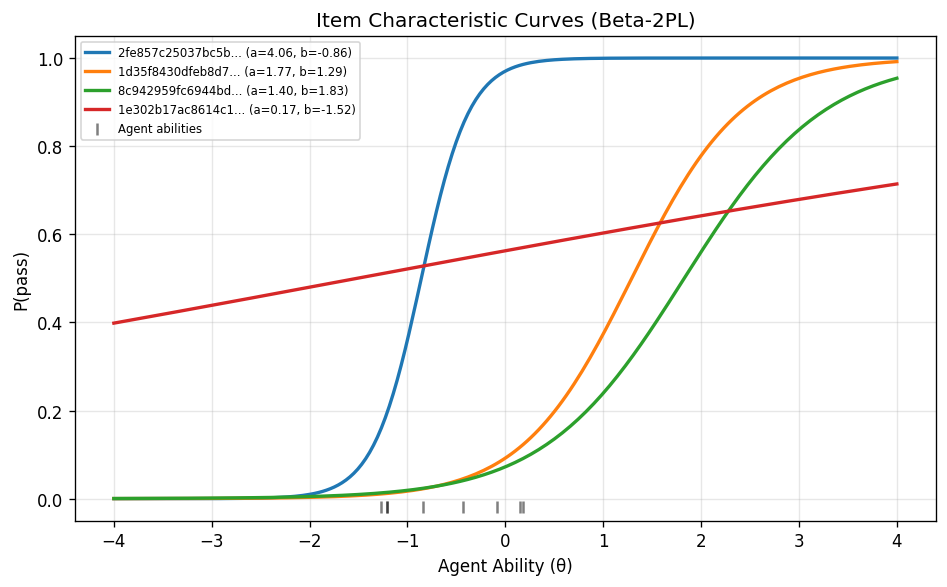

In [16]:
theta_range = torch.linspace(-4, 4, 200)

# Pick tasks with varying difficulty and discrimination
task_indices = [
    disc_ranking[0].item(),     # highest discrimination
    disc_ranking[len(disc_ranking)//4].item(),  # 75th percentile
    disc_ranking[len(disc_ranking)//2].item(),  # median
    disc_ranking[-1].item(),    # lowest discrimination
]

fig, ax = plt.subplots(figsize=(8, 5))
for idx in task_indices:
    a_j = discrimination[idx].item()
    b_j = difficulty[idx].item()
    icc = torch.sigmoid(a_j * (theta_range - b_j))
    label = f"{rm.item_ids[idx][:35]}... (a={a_j:.2f}, b={b_j:.2f})"
    ax.plot(theta_range.numpy(), icc.numpy(), label=label, linewidth=2)

# Overlay actual agent abilities as rug marks
ax.scatter(ability.numpy(), [-0.02] * len(ability), marker="|", color="black", s=50, alpha=0.5, label="Agent abilities")

ax.set_xlabel("Agent Ability (\u03b8)")
ax.set_ylabel("P(pass)")
ax.set_title("Item Characteristic Curves (Beta-2PL)")
ax.legend(fontsize=7, loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 8. Cross-Subset Consistency Check

With a single benchmark, we can check that agent abilities are consistent across different random task subsets — an analogue of the HCAST/RE-Bench/SWAA split in the original METR analysis. We split the tasks into two halves and refit Beta-Rasch on each.

In [17]:
# Split tasks into two halves (odd vs even index) and create two "sub-datasets"
torch.manual_seed(0)
perm = torch.randperm(rm.n_items)
half = rm.n_items // 2
idx_a, idx_b = perm[:half], perm[half:]

rm_a_data = rm.data[:, idx_a]
rm_b_data = rm.data[:, idx_b]

print(f"Subset A: {rm.n_subjects} agents x {idx_a.numel()} tasks, mean={rm_a_data[~rm_a_data.isnan()].mean():.3f}")
print(f"Subset B: {rm.n_subjects} agents x {idx_b.numel()} tasks, mean={rm_b_data[~rm_b_data.isnan()].mean():.3f}")

Subset A: 8 agents x 20 tasks, mean=0.178
Subset B: 8 agents x 20 tasks, mean=0.136


In [18]:
# Fit Beta-Rasch on each subset and compare ability estimates
abilities_by_source = {}
for name, subset_data in [("Subset A", rm_a_data), ("Subset B", rm_b_data)]:
    sd = subset_data.clone().clamp(eps, 1 - eps)
    model = BetaRasch(n_subjects=rm.n_subjects, n_items=sd.shape[1], phi=10.0)
    model.fit(sd, max_epochs=200, lr=0.01, verbose=False)
    abilities_by_source[name] = {
        "ability": model.ability.detach(),
        "subject_ids": rm.subject_ids,
    }
    print(f"{name}: fitted Beta-Rasch on {sd.shape[1]} tasks")

Subset A: fitted Beta-Rasch on 20 tasks


Subset B: fitted Beta-Rasch on 20 tasks


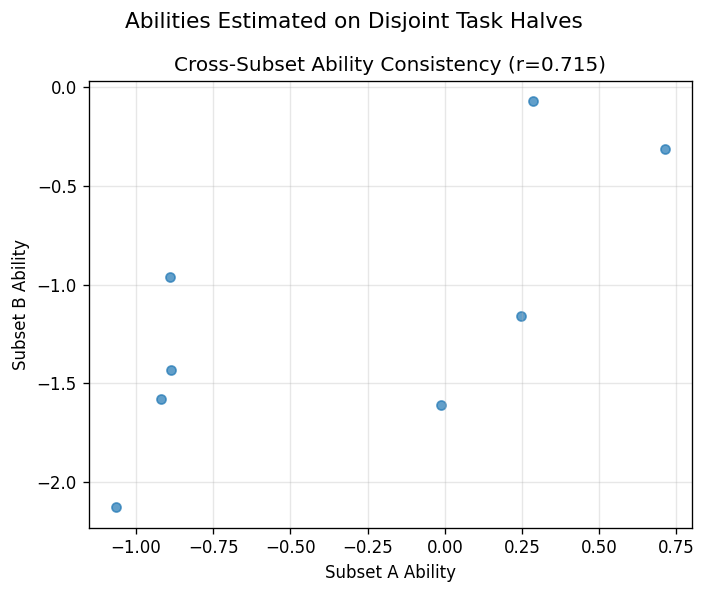

In [19]:
# Cross-subset ability correlation
sources = list(abilities_by_source.keys())
ab_a = abilities_by_source[sources[0]]["ability"]
ab_b = abilities_by_source[sources[1]]["ability"]

r = torch.corrcoef(torch.stack([ab_a, ab_b]))[0, 1].item()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(ab_a.numpy(), ab_b.numpy(), s=30, alpha=0.7)
ax.set_xlabel(f"{sources[0]} Ability")
ax.set_ylabel(f"{sources[1]} Ability")
ax.set_title(f"Cross-Subset Ability Consistency (r={r:.3f})")
ax.grid(True, alpha=0.3)
plt.suptitle("Abilities Estimated on Disjoint Task Halves", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Train/Test Evaluation

We hold out 20% of entries to evaluate how well the Beta-2PL model generalizes.

In [20]:
torch.manual_seed(42)

observed = rm.observed_mask
train_mask, test_mask = random_mask(observed, train_frac=0.8)

print(f"Training entries: {train_mask.sum().item():,}")
print(f"Test entries:     {test_mask.sum().item():,}")

# Fit Beta-2PL on training data only
model_eval = BetaTwoPL(n_subjects=n_subjects, n_items=n_items, phi=10.0)
history_eval = model_eval.fit(data, mask=train_mask, max_epochs=200, lr=0.01, verbose=False)

# Evaluate on held-out entries
probs = model_eval.predict().detach()
ece = expected_calibration_error(probs, data, mask=test_mask)
bs = brier_score(probs, data, mask=test_mask)

print(f"\nTest set metrics:")
print(f"  Expected Calibration Error: {ece:.4f}")
print(f"  Brier Score: {bs:.4f}")

Training entries: 263
Test entries:     57



Test set metrics:
  Expected Calibration Error: 0.0321
  Brier Score: 0.0147


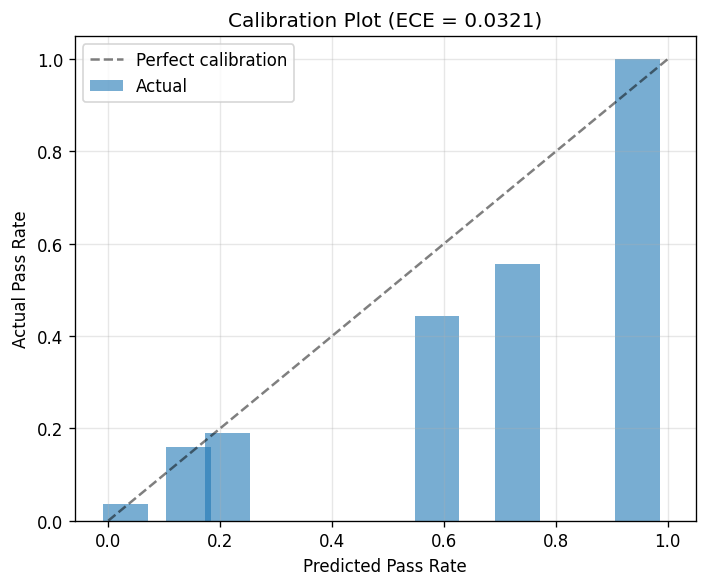

In [21]:
# Calibration plot: predicted vs. actual pass rates in bins
test_probs = probs[test_mask]
test_actual = data[test_mask]

n_bins = 10
bin_edges = torch.linspace(0, 1, n_bins + 1)
bin_accs = []
bin_confs = []
bin_sizes = []

for i in range(n_bins):
    mask_bin = (test_probs >= bin_edges[i]) & (test_probs < bin_edges[i + 1])
    if mask_bin.sum() > 0:
        bin_accs.append(test_actual[mask_bin].mean().item())
        bin_confs.append(test_probs[mask_bin].mean().item())
        bin_sizes.append(mask_bin.sum().item())

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(bin_confs, bin_accs, width=0.08, alpha=0.6, label="Actual")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
ax.set_xlabel("Predicted Pass Rate")
ax.set_ylabel("Actual Pass Rate")
ax.set_title(f"Calibration Plot (ECE = {ece:.4f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Uncertainty Quantification

Fisher information-based standard errors quantify how precisely each agent's ability is estimated.

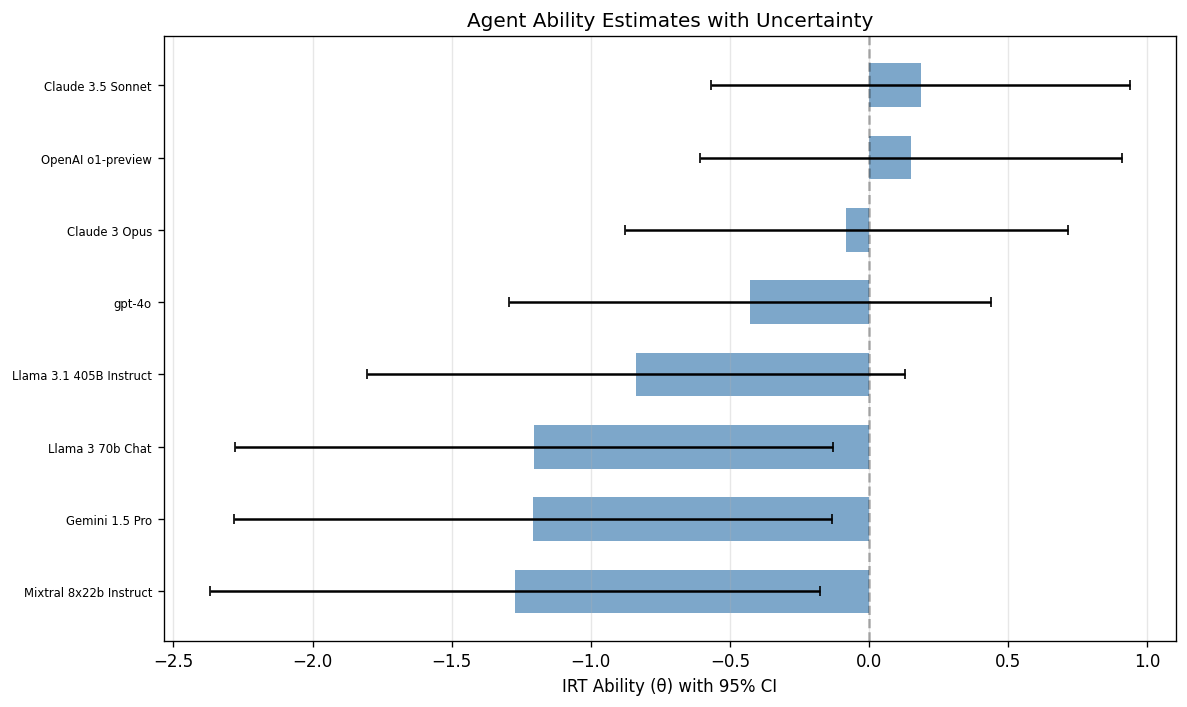

In [22]:
# Standard errors from the full Beta-2PL model
ability_full = beta_2pl.ability.detach()
difficulty_full = beta_2pl.difficulty.detach()

se_ability = ability_standard_errors(ability_full, difficulty_full)

# Plot ability estimates with 95% confidence intervals
sorted_idx = ability_full.argsort()
sorted_ab = ability_full[sorted_idx]
sorted_se = se_ability[sorted_idx]
sorted_names = [rm.subject_ids[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(sorted_ab))
ax.barh(y_pos, sorted_ab.numpy(), xerr=(1.96 * sorted_se).numpy(), height=0.6,
        alpha=0.7, capsize=3, color="steelblue")
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_names, fontsize=7)
ax.set_xlabel("IRT Ability (\u03b8) with 95% CI")
ax.set_title("Agent Ability Estimates with Uncertainty")
ax.axvline(x=0, color="k", linestyle="--", alpha=0.3)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 11. Comparison: Beta IRT vs. Standard IRT on Binarized Data

We can also binarize the pass rates (threshold at 0.5) and fit standard IRT models. This lets us compare whether the continuous Beta IRT captures more information.

Binarized accuracy: 0.103


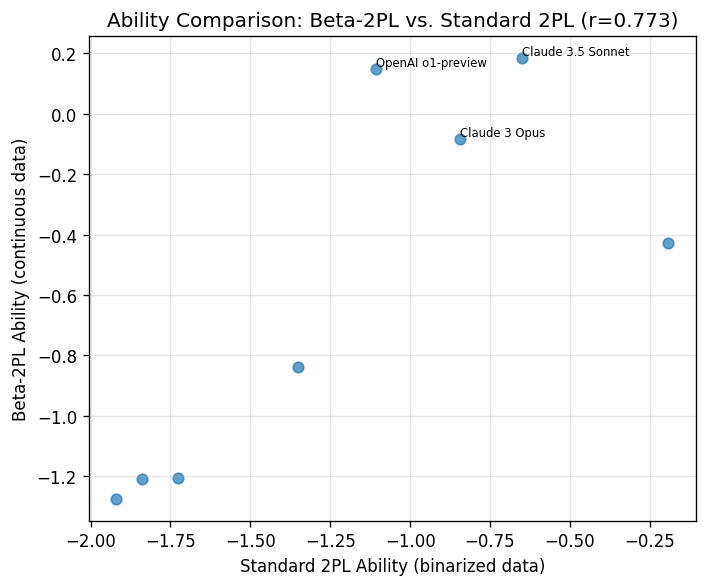

Correlation: 0.773
Beta-2PL retains graded information that binarization discards.


In [23]:
# Binarize: pass rate > 0.5 → 1, else → 0
binary_data = binarize(rm.data, threshold=0.5)
print(f"Binarized accuracy: {binary_data[~torch.isnan(binary_data)].mean():.3f}")

# Fit standard Rasch and 2PL on binary data
rasch_bin = Rasch(n_subjects=n_subjects, n_items=n_items)
twopl_bin = TwoPL(n_subjects=n_subjects, n_items=n_items)

rasch_bin.fit(binary_data, max_epochs=200, verbose=False)
twopl_bin.fit(binary_data, max_epochs=200, verbose=False)

# Compare ability estimates: Beta-2PL vs. standard 2PL
ability_beta = beta_2pl.ability.detach()
ability_bin = twopl_bin.ability.detach()

r = torch.corrcoef(torch.stack([ability_beta, ability_bin]))[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(ability_bin.numpy(), ability_beta.numpy(), s=40, alpha=0.7)
for idx in list(ability_ranking[:3]):
    ax.annotate(rm.subject_ids[idx], (ability_bin[idx].item(), ability_beta[idx].item()),
                fontsize=7, ha="left", va="bottom")
ax.set_xlabel("Standard 2PL Ability (binarized data)")
ax.set_ylabel("Beta-2PL Ability (continuous data)")
ax.set_title(f"Ability Comparison: Beta-2PL vs. Standard 2PL (r={r:.3f})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Correlation: {r:.3f}")
print("Beta-2PL retains graded information that binarization discards.")

## 12. Psychometric Quality: Reliability and Item Fit

We assess the quality of the METR evaluation using classical psychometric diagnostics on the binarized data.

In [24]:
# Cronbach's alpha on binarized data
alpha = cronbach_alpha(binary_data)
print(f"Cronbach's alpha: {alpha:.3f}")
print(f"  (> 0.9 = excellent, 0.8-0.9 = good, 0.7-0.8 = acceptable)")

# Item fit statistics
probs_rasch_bin = rasch_bin.predict().detach()
infit = infit_statistics(probs_rasch_bin, binary_data)
outfit = outfit_statistics(probs_rasch_bin, binary_data)

print(f"\nInfit MNSQ  — mean: {infit.mean():.3f}, range: [{infit.min():.3f}, {infit.max():.3f}]")
print(f"Outfit MNSQ — mean: {outfit.mean():.3f}, range: [{outfit.min():.3f}, {outfit.max():.3f}]")

n_underfit = (infit > 1.3).sum().item()
n_overfit = (infit < 0.7).sum().item()
print(f"\nItems: {n_underfit} underfit (infit > 1.3), {n_overfit} overfit (infit < 0.7) out of {n_items}")

Cronbach's alpha: 0.706
  (> 0.9 = excellent, 0.8-0.9 = good, 0.7-0.8 = acceptable)

Infit MNSQ  — mean: 0.200, range: [0.004, 0.965]
Outfit MNSQ — mean: 0.166, range: [0.003, 0.891]

Items: 0 underfit (infit > 1.3), 33 overfit (infit < 0.7) out of 40


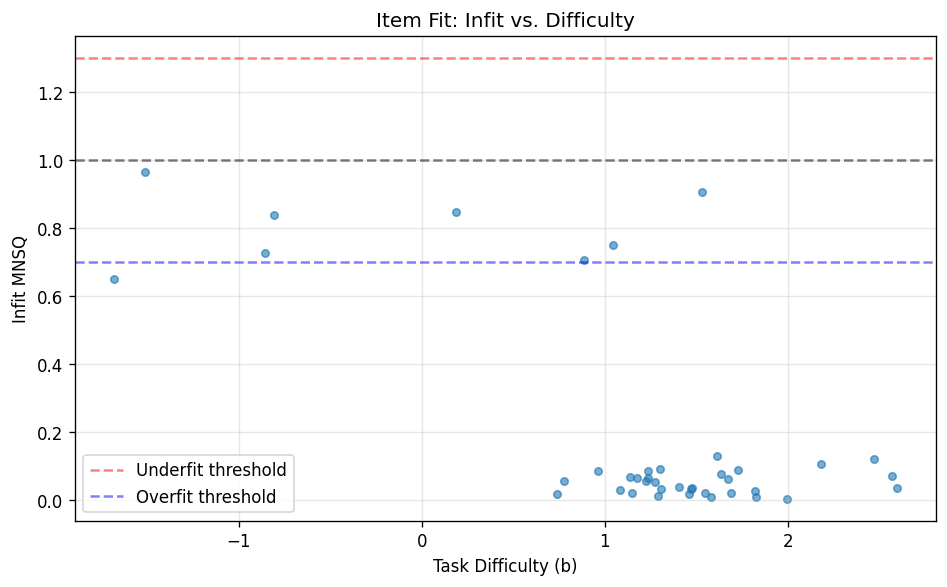

In [25]:
# Item fit visualization
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(difficulty_full.numpy(), infit.numpy(), alpha=0.6, s=20)
ax.axhline(y=1.0, color="k", linestyle="--", alpha=0.5)
ax.axhline(y=1.3, color="r", linestyle="--", alpha=0.5, label="Underfit threshold")
ax.axhline(y=0.7, color="b", linestyle="--", alpha=0.5, label="Overfit threshold")
ax.set_xlabel("Task Difficulty (b)")
ax.set_ylabel("Infit MNSQ")
ax.set_title("Item Fit: Infit vs. Difficulty")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Wright Map (Person-Item Map)

A Wright map displays both agent abilities and task difficulties on the same logit scale, making it easy to see how well the tasks cover the ability range.

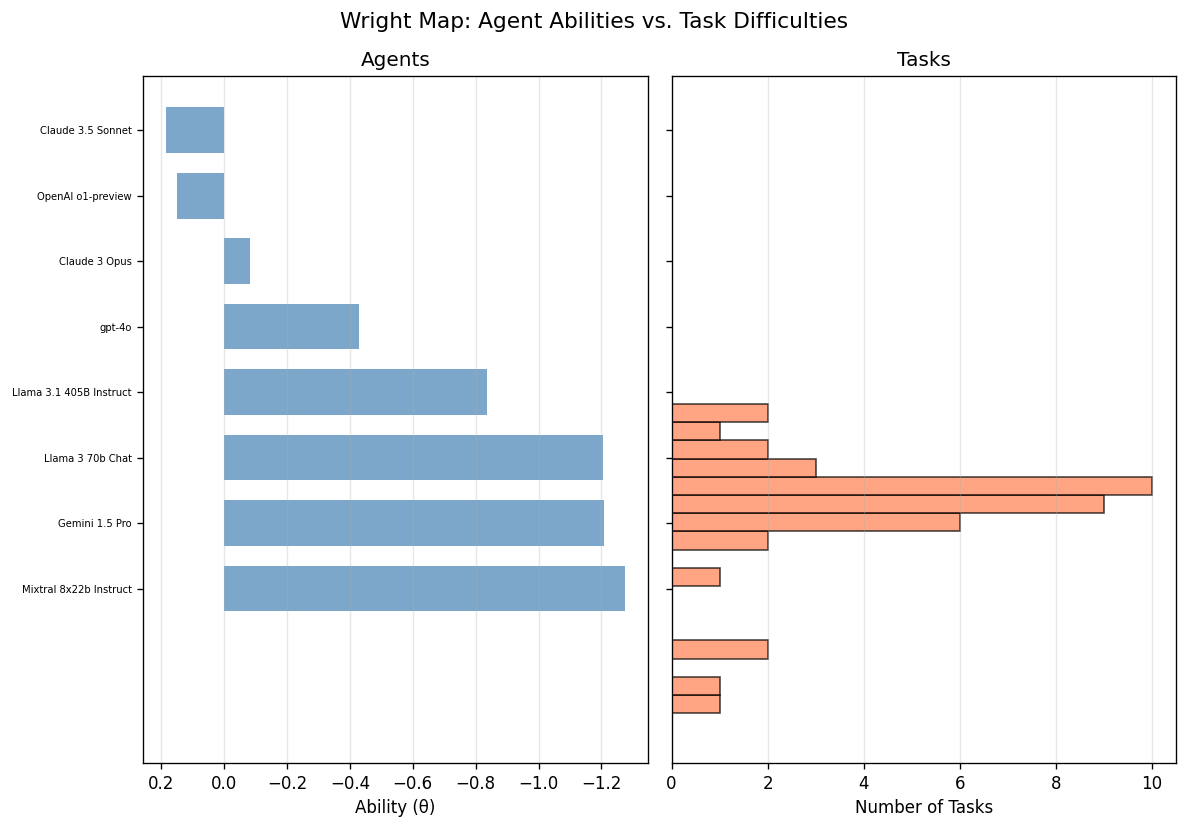

In [26]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10, 7), sharey=True,
                                         gridspec_kw={"width_ratios": [1, 1]})

# Left: agent ability distribution
y_vals = ability_full.numpy()
ax_left.barh(range(len(y_vals)), y_vals[ability_full.argsort().numpy()],
             height=0.7, color="steelblue", alpha=0.7)
ax_left.set_yticks(range(len(y_vals)))
ax_left.set_yticklabels([rm.subject_ids[i] for i in ability_full.argsort()], fontsize=6)
ax_left.set_xlabel("Ability (\u03b8)")
ax_left.set_title("Agents")
ax_left.grid(True, alpha=0.3, axis="x")
ax_left.invert_xaxis()

# Right: task difficulty histogram (horizontal)
bins = np.linspace(difficulty_full.min().item() - 0.5, difficulty_full.max().item() + 0.5, 20)
ax_right.hist(difficulty_full.numpy(), bins=bins, orientation="horizontal",
              color="coral", alpha=0.7, edgecolor="black")
ax_right.set_xlabel("Number of Tasks")
ax_right.set_title("Tasks")
ax_right.grid(True, alpha=0.3, axis="x")

plt.suptitle("Wright Map: Agent Abilities vs. Task Difficulties", fontsize=13)
plt.tight_layout()
plt.show()

## Summary

In this tutorial we:

1. **Loaded** the METR agentic evaluation dataset using `torch_measure.datasets.load("metr/all")`
2. **Explored** the response matrix: 34 agents x 170 tasks with continuous pass rates
3. **Fitted Beta IRT models** (BetaRasch, BetaTwoPL) designed for continuous [0, 1] responses
4. **Ranked agents** by IRT ability — a principled alternative to raw pass rates
5. **Analyzed task difficulty and discrimination** via the 2PL model
6. **Compared across task sources** (HCAST, RE-Bench, SWAA) to check ability consistency
7. **Evaluated generalization** with train/test splitting and calibration metrics
8. **Quantified uncertainty** with Fisher-based standard errors
9. **Compared Beta IRT vs. standard IRT** on binarized data
10. **Assessed psychometric quality** with Cronbach's alpha, infit/outfit statistics

### Key Takeaways

- **Beta IRT** is the natural choice for multi-run pass-rate data — it retains graded information that binarization discards
- **IRT ability** provides a difficulty-adjusted ranking of agents, unlike raw pass rates which treat all tasks equally
- **Task discrimination** reveals which tasks are most informative for distinguishing agent capabilities
- The METR dataset's high density (99%+) and diverse task range make it ideal for IRT analysis

### References

- METR (2025). *Measuring AI Ability to Complete Long Tasks.* [GitHub](https://github.com/METR/eval-analysis-public)
- Noel, Y. & Dauvier, B. (2007). *A Beta Item Response Model for Continuous Bounded Responses.* Applied Psychological Measurement.